In [227]:
import matplotlib
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML
import os 
from pathlib import Path
import re
import pandas as pd


def initplot():
    # Define the locations for the axes
    left,   right  = 0.14, 0.82
    bottom, height = 0.12, 0.80
    
    # Set up the geometry of the three plot
    rect = [left, bottom, right, height]   # dimensions of temp plot
    fig = plt.figure(1, figsize=(6,6))
    ax      = plt.axes(rect)
    ax.tick_params(axis="both",which="both",top='on', bottom='on', left='on', right='on',direction="in", pad=10)
    return ax,fig

plt.rc('text', usetex=True)
cmap = "viridis"
fsize = 15
lsize = 15
family = 'Times New Roman'
matplotlib.rcParams.update({'font.size': fsize})
matplotlib.rcParams.update({'font.family': family})

dpur = '#440154' # dark purple
purp = '#472c7a' # purple
blu2 = '#3b518b' # blue
blu3 = '#2c718e' # blue
blgr = '#21908d' # blue-green
gre1 = '#27ad81' # green
gre2 = '#5cc863' # green
lgre = '#aadc32' # lime green
yell = '#fde725' # yellow


In [228]:
#Scaling units of your simulation
#R*: Half-mass radius in pc
#M*: mass in solar masses
#V*: velocity in km/s
#T*: time in Myr

#!grep 'PHYSICAL SCALING' examples/TEST_SPZ/chnk0/run_Arca.1184860.out
#Tstar = 1.054247560742E-02

MovieWriter ffmpeg unavailable; using Pillow instead.


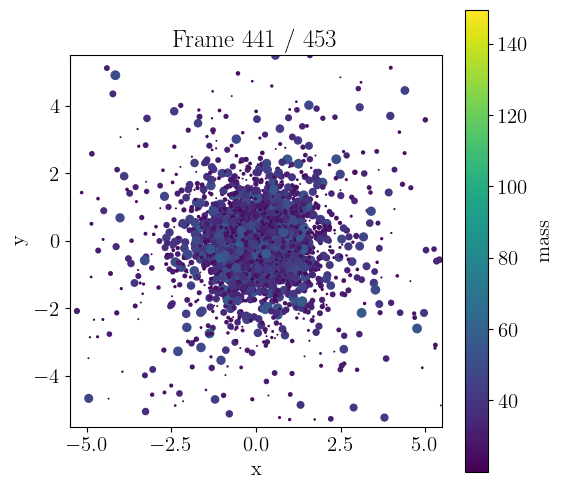

In [229]:

## Here we create an animation of our simulation ##

def readfiles(path,fname):    
    root = Path(path)
#candidates = [p for p in root.rglob("single.40_*") if p.is_file()
    dir_num = re.compile(r'(\d+)$')
    last_int = dir_num
    def index_of(p: Path) -> int:
        m = last_int.search(p.name)
        if not m:
            raise ValueError(f"Can't parse index from: {p.name!r}")
        return int(m.group(1))
        
    files = sorted(
        (p for p in root.rglob(fname+"*") if p.is_file()),
        key=index_of
    )
    return files
    


directory="examples/TEST_SPZ/"
subdir = "chnk"
chunks = 9

fl_sin = "single.40_"
files = readfiles(directory, fl_sin)

xlim = 5.5
ylim = 5.5


fps = 10       # frame per second
out_mp4 = None # "stars.mp4"      # or set to None if you only want to show
out_gif = "stars.gif"             # e.g. "stars.gif"

# axis limits: set explicitly for a stable camera
xlim = (-xlim, xlim)
ylim = (-ylim, ylim)

# mass->marker mapping
min_size, max_size = 2, 50   # marker areas in points^2
# ----------------------------------


def load_frame(path):
    """
    Expected columns: x y mass (whitespace/csv both ok if you adjust delimiter)
    """
    data_s = np.loadtxt(path, usecols=[5,6,2], comments="##", skiprows=2)  # if CSV: np.loadtxt(path, delimiter=",")
    x, y, m = data_s[:, 0], data_s[:, 1], data_s[:, 2]
    return x, y, m

def mass_to_size(m):
    # Robust scaling using percentiles to avoid a few huge masses dominating
    lo, hi = np.percentile(m, [5, 95])
    m_clip = np.clip(m, lo, hi)
    t = (m_clip - lo) / (hi - lo + 1e-12)
    return min_size + t * (max_size - min_size)


# initialize from first frame
x0, y0, m0 = load_frame(files[0])
s0 = mass_to_size(m0)

## Movie of the simulation ##
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x")
ax.set_ylabel("y")
title = ax.set_title(f"Frame 1 / {len(files)}")

# Scatter plot: using edgecolors='none' for speed
sc = ax.scatter(x0, y0, s=s0, c=m0, cmap="viridis", edgecolors="none")
cbar = fig.colorbar(sc, ax=ax, label="mass")

def init():
    sc.set_offsets(np.c_[x0, y0])
    sc.set_sizes(s0)
    sc.set_array(m0)  # updates colormap scaling data
    title.set_text(f"Frame 1 / {len(files)}")
    return sc, title

def update(i):
    x, y, m = load_frame(files[i])
    sc.set_offsets(np.c_[x, y])
    sc.set_sizes(mass_to_size(m))
    sc.set_array(m)
    title.set_text(f"Frame {i+1} / {len(files)}")
    return sc, title

anim = FuncAnimation(
    fig,
    update,
    frames=range(0, len(files), 20),
    init_func=init,
    interval= 2500 / fps,
    blit=True
)

# Save outputs
if out_mp4:
    # Requires ffmpeg installed
    anim.save(out_mp4, fps=fps, dpi=150)
if out_gif:
    # Requires pillow installed
    anim.save(out_gif, fps=fps)

HTML(anim.to_jshtml())

In [230]:

def collate_files(path, fname, nrows):
    root = Path(path)

    dir_num = re.compile(r'(\d+)$')
    def dkey(d: Path) -> int:
        m = dir_num.search(d.name)
        if not m:
            raise ValueError(f"Unexpected dir name: {d.name!r}")
        return int(m.group(1))

    paths = [
        d / fname
        for d in sorted((p for p in root.iterdir() if p.is_dir()), key=dkey)
        if (d / fname).is_file()
    ]

    
    dfs = []
    for p in paths:
        if p.stat().st_size == 0:
            print(f"Skipping empty file: {path}")
            continue
        df = pd.read_csv(
            p,
            sep=r"\s+",
            header=None,        # first line = column names
            skiprows=nrows,    # skip the second header line
            engine="python"
        )
        
        dfs.append(df)

    big = pd.concat(dfs, ignore_index=True)
    return big
    

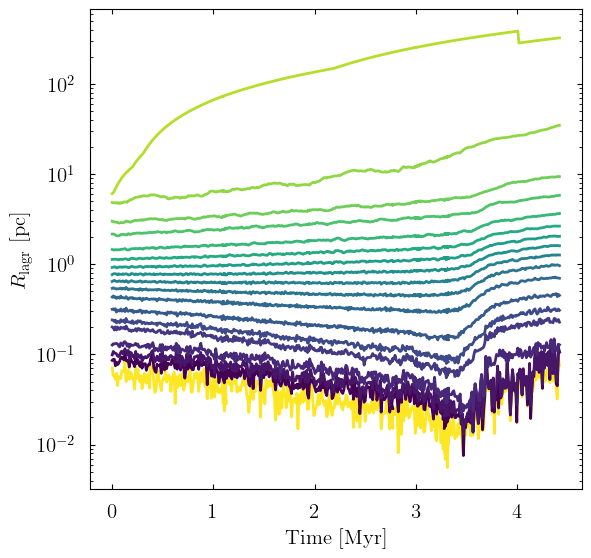

In [231]:
## The lagr.7 file contains the lagrangian radii for the whole system, for single and binary stars, as well as
## information about the mass, velocity dispersion, rotation velocity in different shells containing x% of the total cluster mass
## Columns 2-20 represent lagrangian radii enclosing:
## 0.001,0.003,0.005,0.01,0.03,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99,1.0 of the total mass

lagr7 = "lagr.7"

X = collate_files(directory, lagr7,2)

## Movie of the simulation ##
ax, fig = initplot()
cmap = plt.get_cmap("viridis")
values = np.linspace(0, 1, 19)      # normalized positions
colors = cmap(values)              # shape: (N, 4) RGBA
for i in range(1,19):
    ax.plot(Tstar*X[0],X[i],lw=2,color=colors[i-2])

#sss = ["0.001","0.003","0.005","0.01","0.03","0.05","0.1","0.2","0.3","0.4","0.5","0.6","0.7","0.8","0.9","0.95","0.99","1.0"]
#for i in range(1,19):
#    ax.text(1.05*X[-1,0],X[-1,i],sss[i-1], horizontalalignment='center', verticalalignment='center', fontsize=12)
plt.xlabel("Time [Myr]")
plt.ylabel("$R_{\\rm lagr}$ [pc]")
plt.yscale("log")
#plt.xlim(0,500)
plt.show()


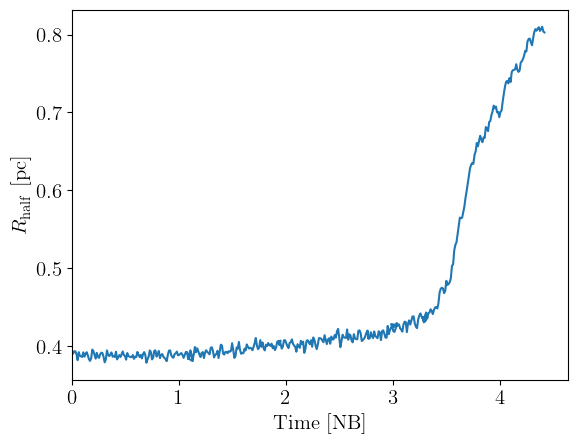

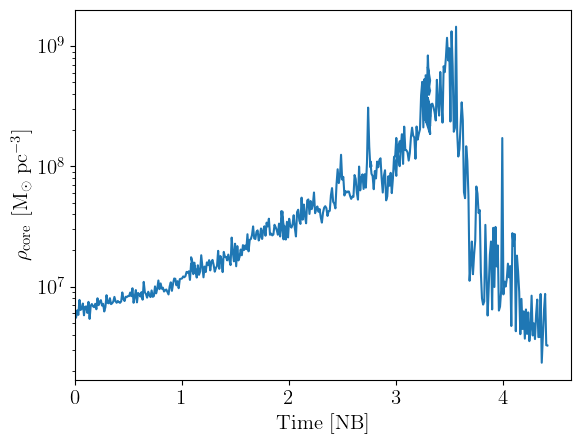

In [232]:
## General files
glob30 = "global.30"

X = collate_files(directory, glob30,2)

time = X[0]*Tstar
half = X[5]
core = X[8]
mcor = X[11]

plt.plot(time, half)
plt.xlabel("Time [NB]")
plt.ylabel("$R_{\\rm half}$ [pc]")
plt.xlim(xmin=0)
plt.show()


plt.plot(time,mcor/pow(core,3.))
plt.xlabel("Time [NB]")
plt.ylabel("${\\rho}_{\\rm core}$ [M$_\odot$ pc$^{-3}$]")
plt.xlim(xmin=0)
plt.yscale("log")
plt.show()



/tmp/ipykernel_186961/1169130685.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend(loc="upper right", title="T = {0:1.2f} Myr".format(Tstar*i))


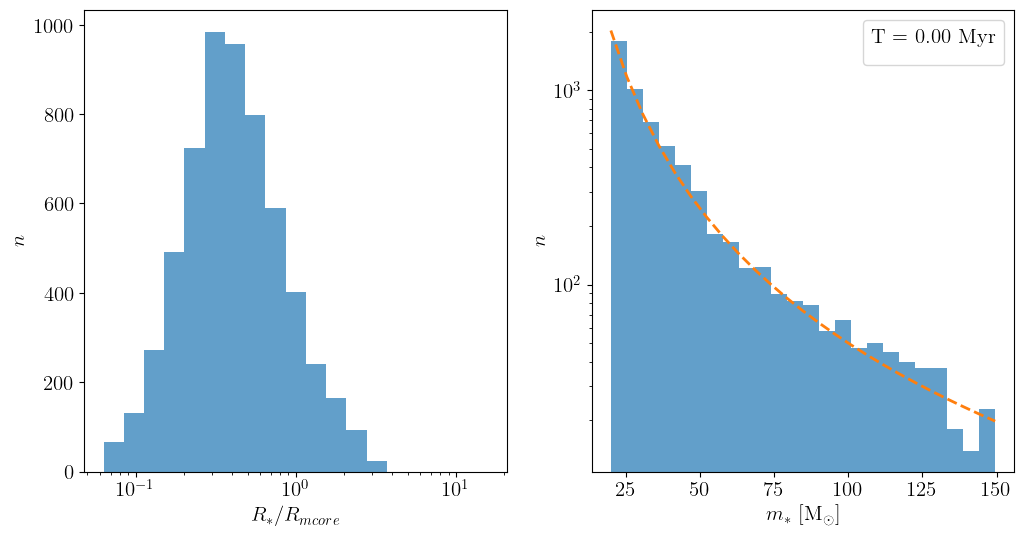

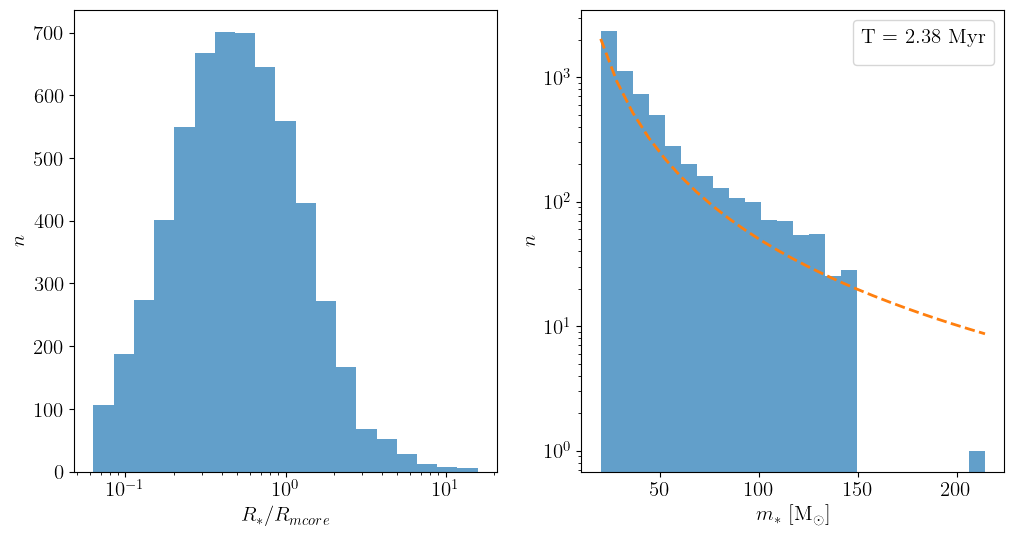

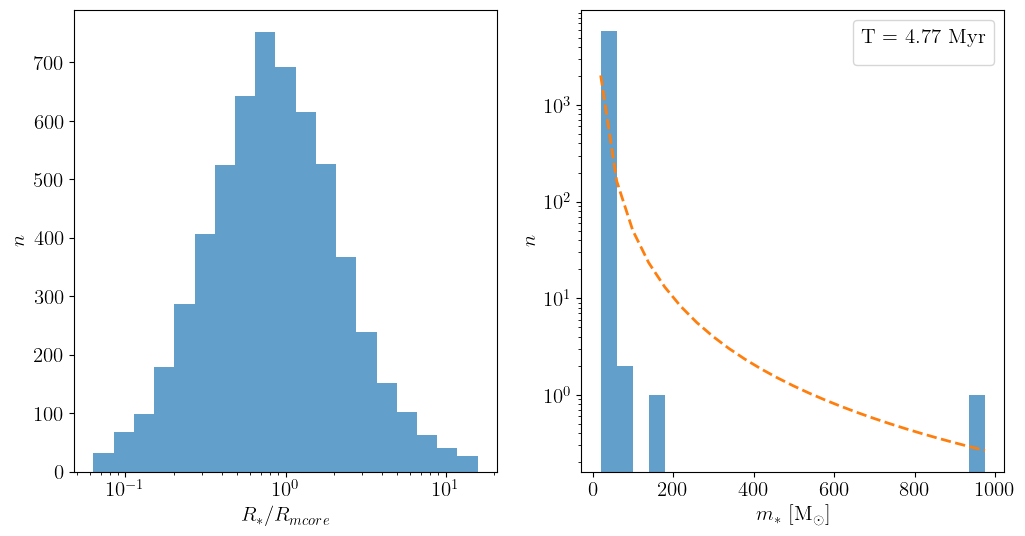

In [233]:
## Simplified output for single and binary stars

sev = readfiles(directory,"sev.83_")

for i in range(0,len(sev),int(len(sev)/2)):
    
    X = np.loadtxt(sev[i], usecols=[4,5], skiprows=1)

    figure, axs = plt.subplots(1,2,figsize=(12, 6))

    axs[0].hist(X[:,0], bins=np.logspace(-1.2,1.2,20),histtype="stepfilled", alpha=0.7)
    axs[0].set_xlabel("$R_*/R_{\rm core}$")
    axs[0].set_ylabel("$n$")
    axs[0].set_xscale("log")

    axs[1].hist(X[:,1], bins=np.linspace(min(X[:,1]),max(X[:,1]),25),histtype="stepfilled", alpha=0.7)

    x_aux = np.linspace(min(X[:,1]),max(X[:,1]),25)
    y_aux = 50.*(x_aux/100.)**-2.3
    axs[1].plot(x_aux, y_aux,lw=2,linestyle="--")

    axs[1].set_xlabel("$m_*$ [M$_\odot$]")
    axs[1].set_ylabel("$n$")
    axs[1].set_yscale("log")

    axs[1].legend(loc="upper right", title="T = {0:1.2f} Myr".format(Tstar*i))
    plt.show()



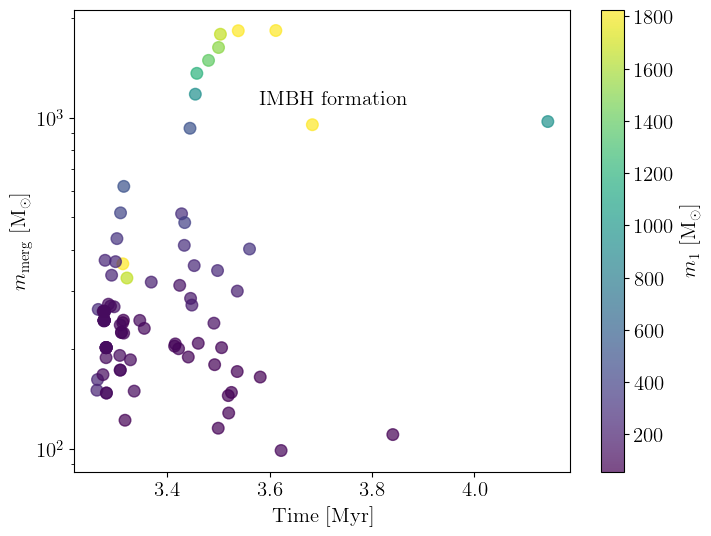

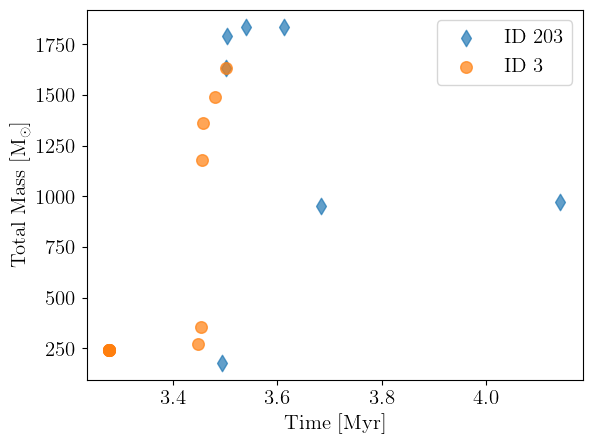

In [234]:
def empty(fname):
    idx = 0
    if Path(fname).stat().st_size == 0:
        #print("File is empty")
        idx = 1
    return idx
    
coal24 = "coal.24"


Y = []
fig = plt.figure(figsize=(8,6))
for i in range(chunks+1):
    
    fname = directory+"/chnk"+str(i)+"/"+coal24
    idx = empty(fname)
    if(idx == 1):
        continue
        
    X = np.loadtxt(fname,dtype={'names':('time','m1','m2','id1','id2','mfin','kfin','k1','k2','ctype'), 
                                 'formats':(float,float,float,int,int,float,int,int,int,'U8')},
                   usecols = [2,16,17,3,4,18,7,5,6,0], comments=["MODEL", "WHICH"])

    Y.append(X[['time','m1','m2','id1','id2','k1','k2','ctype','mfin']])
    
    Mmax = np.maximum(X['m1'], X['m2'])
    
    plt.scatter(X['time']*Tstar, X['mfin'], c=Mmax, marker="o", s=70, alpha=0.7)

    
plt.text(3.58,1.1e3,"IMBH formation")
plt.xlabel("Time [Myr]")
plt.ylabel("$m_{\\rm merg}$ [M$_\odot$]")
plt.colorbar(label="$m_1$ [M$_\odot$]")
plt.yscale("log")
plt.show()

#All coalescences occur when at least one component is in coHeb phase 
Y_c = np.concatenate(Y)

idx = np.where((Y_c['id1'] == 203) | (Y_c['id2'] == 203))
plt.scatter(Y_c['time'][idx]*Tstar, Y_c['mfin'][idx], label="ID 203", marker="d", s=70, alpha=0.7)
idx = np.where((Y_c['id1'] == 3) | (Y_c['id2'] == 3))
plt.scatter(Y_c['time'][idx]*Tstar, Y_c['mfin'][idx], label="ID 3", marker="o", s=70, alpha=0.7)
plt.xlabel("Time [Myr]")
plt.ylabel("Total Mass [M$_\odot$]")
plt.legend(loc="upper right")
plt.show()

In [235]:
#Thanks for your attention and patience :)